# NB05 — Baseline Imagem (MLP sobre embeddings MobileNetV2)

## Objetivo
Treinar um modelo simples sobre os embeddings de imagem pré-calculados no NB02
(MobileNetV2, 1280 dimensões) para estabelecer o **baseline unimodal visual** da
pipeline multimodal.

## Contexto
Terceiro (e último) baseline unimodal antes da fusão no NB06:

| Baseline | Framework | Input | Val ROC-AUC |
|----------|-----------|-------|-------------|
| NB03 Tabular | LightGBM | 50 features estruturadas | 0.6758 |
| NB04 Texto | sklearn MLP | MiniLM 384-dim | 0.5469 |
| **NB05 Imagem** | **sklearn MLP** | **MobileNetV2 1280-dim** | **?** |

## Decisão de framework
Usamos `sklearn.neural_network.MLPClassifier` (não Keras/TF) por dois motivos:
1. **Consistência metodológica**: comparação justa com o NB04 exige mesma framework.
2. **Conflito de dependências**: TF 2.16 exige `numpy<2.0`, pandas 3.x exige `numpy>=2.0`. Conflito deixado para resolver no NB06, onde TF terá mais valor
   (rede de fusão Dense).

## Estratégia
Replicar a estrutura do NB04:
- Treinar 3 configurações MLP com regularização crescente (α=1e-4, 1e-2, 5e-2)
- Avaliar overfitting via gap `train_ROC-AUC − val_ROC-AUC`
- Escolher o modelo com **menor gap**, não o de maior val ROC-AUC (robustez > performance)

## Atenção especial
- **341 animais (2.27%) sem foto**: embedding é placeholder de zeros no NB02.
  Análogo aos 809 sem descrição no NB04. Diagnosticar antes do treino.
- Target balanceado (50.27% / 49.73%) → métricas diretas, sem class_weight.
- Splits StratifiedGroupKFold por RescuerID já consolidados no `splits_index.parquet`.

## Output esperado
- 3 modelos treinados em `results/nb05_baseline_imagem/`
- Previsões val/test do modelo oficial
- `model_comparison.csv` e `metrics.json` (análogos ao NB04)
- Findings para o NB06

In [1]:
# ============================================================================
# NB05 — Baseline Imagem (MLP sobre embeddings MobileNetV2)
# Célula 2: Imports, paths e configuração de reprodutibilidade
# ============================================================================

# --- Standard library ---
import json
import warnings
from pathlib import Path

# --- Scientific stack ---
import numpy as np
import pandas as pd

# --- Modelação e avaliação ---
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

# --- Persistência ---
import joblib

# --- Visualização ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuração ---
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Paths ---
PROJECT_ROOT = Path.cwd().parent  # assumindo que o notebook está em /notebooks
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
CACHE_DIR = DATA_DIR / "cache"
RESULTS_DIR = PROJECT_ROOT / "results" / "nb05_baseline_imagem"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# --- Verificação rápida ---
print("=" * 70)
print("NB05 — Baseline Imagem | Configuração do ambiente")
print("=" * 70)
print(f"Python numpy     : {np.__version__}")
print(f"Python pandas    : {pd.__version__}")
print(f"Random state     : {RANDOM_STATE}")
print()
print(f"PROJECT_ROOT     : {PROJECT_ROOT}")
print(f"PROCESSED_DIR    : {PROCESSED_DIR}  (existe: {PROCESSED_DIR.exists()})")
print(f"CACHE_DIR        : {CACHE_DIR}      (existe: {CACHE_DIR.exists()})")
print(f"RESULTS_DIR      : {RESULTS_DIR}    (criado)")

NB05 — Baseline Imagem | Configuração do ambiente
Python numpy     : 2.4.4
Python pandas    : 3.0.2
Random state     : 42

PROJECT_ROOT     : /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder
PROCESSED_DIR    : /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/data/processed  (existe: True)
CACHE_DIR        : /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/data/cache      (existe: True)
RESULTS_DIR      : /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/results/nb05_baseline_imagem    (criado)


In [2]:
# ============================================================================
# Célula 3: Carregar splits_index + embeddings MobileNetV2 + PetIDs
# ============================================================================

# --- 1. Carregar o mapa central de splits ---
splits_index = pd.read_parquet(PROCESSED_DIR / "splits_index.parquet")

print("splits_index")
print("-" * 70)
print(f"Shape            : {splits_index.shape}")
print(f"Colunas          : {list(splits_index.columns)}")
print(f"Dtypes           :\n{splits_index.dtypes}")
print()
print("Distribuição por split:")
print(splits_index["split"].value_counts().sort_index())
print()
print("Balanço do target por split (proporção de y=1):")
print(splits_index.groupby("split")["y"].mean().round(4))
print()

# --- 2. Carregar embeddings de imagem ---
image_embeddings = np.load(CACHE_DIR / "image_embeddings_mobilenetv2.npy")
image_petids = np.load(CACHE_DIR / "image_embeddings_petids.npy", allow_pickle=True)

print("image_embeddings_mobilenetv2.npy")
print("-" * 70)
print(f"Shape            : {image_embeddings.shape}")
print(f"Dtype            : {image_embeddings.dtype}")
print(f"Min / Max        : {image_embeddings.min():.4f} / {image_embeddings.max():.4f}")
print(f"Mean / Std       : {image_embeddings.mean():.4f} / {image_embeddings.std():.4f}")
print()

print("image_embeddings_petids.npy")
print("-" * 70)
print(f"Shape            : {image_petids.shape}")
print(f"Dtype            : {image_petids.dtype}")
print(f"Primeiros 3 IDs  : {image_petids[:3].tolist()}")
print()

# --- 3. Verificação de integridade crítica ---
assert image_embeddings.shape[0] == splits_index.shape[0] == image_petids.shape[0], (
    "Desalinhamento: o número de linhas tem de coincidir nas três estruturas."
)

# Os PetIDs no ficheiro de embeddings estão na mesma ordem que splits_index?
same_order = np.array_equal(image_petids, splits_index["PetID"].values)
print(f"PetIDs alinhados com splits_index (mesma ordem)? {same_order}")

splits_index
----------------------------------------------------------------------
Shape            : (14993, 4)
Colunas          : ['PetID', 'split', 'y', 'RescuerID']
Dtypes           :
PetID          str
split          str
y            int64
RescuerID      str
dtype: object

Distribuição por split:
split
test     2997
train    9600
val      2396
Name: count, dtype: int64

Balanço do target por split (proporção de y=1):
split
test     0.5025
train    0.5027
val      0.5029
Name: y, dtype: float64

image_embeddings_mobilenetv2.npy
----------------------------------------------------------------------
Shape            : (14993, 1280)
Dtype            : float32
Min / Max        : 0.0000 / 5.9772
Mean / Std       : 0.3857 / 0.5588

image_embeddings_petids.npy
----------------------------------------------------------------------
Shape            : (14993,)
Dtype            : object
Primeiros 3 IDs  : ['6296e909a', '5842f1ff5', '850a43f90']

PetIDs alinhados com splits_index (mesma ordem

In [ ]:
# ============================================================================
# Célula 4: Construir matrizes X (embeddings) e vetores y (target) por split
# ============================================================================

# --- 1. Máscaras booleanas por split ---
mask_train = (splits_index["split"] == "train").values
mask_val   = (splits_index["split"] == "val").values
mask_test  = (splits_index["split"] == "test").values

# --- 2. Aplicar as máscaras ---
X_train = image_embeddings[mask_train]
X_val   = image_embeddings[mask_val]
X_test  = image_embeddings[mask_test]

y_train = splits_index.loc[mask_train, "y"].values
y_val   = splits_index.loc[mask_val,   "y"].values
y_test  = splits_index.loc[mask_test,  "y"].values

# PetIDs por split — necessários para gravar as previsões no fim
petids_val  = splits_index.loc[mask_val,  "PetID"].values
petids_test = splits_index.loc[mask_test, "PetID"].values

# --- 3. Verificações ---
print("Shapes após split")
print("-" * 70)
print(f"X_train : {X_train.shape}   |   y_train : {y_train.shape}")
print(f"X_val   : {X_val.shape}    |   y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   |   y_test  : {y_test.shape}")
print()

print("Balanço do target (sanity check — deve bater com a célula 3)")
print("-" * 70)
print(f"y_train mean : {y_train.mean():.4f}")
print(f"y_val   mean : {y_val.mean():.4f}")
print(f"y_test  mean : {y_test.mean():.4f}")
print()

# --- 4. Dtype check (evita surpresas no MLPClassifier) ---
print("Dtypes")
print("-" * 70)
print(f"X_train dtype : {X_train.dtype}")
print(f"y_train dtype : {y_train.dtype}")
print()

# --- 5. Totais ---
total = X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
assert total == splits_index.shape[0], "Alguma linha ficou perdida no split!"
print(f"Total de linhas distribuídas : {total} / {splits_index.shape[0]} ✓")

Shapes após split
----------------------------------------------------------------------
X_train : (9600, 1280)   |   y_train : (9600,)
X_val   : (2396, 1280)    |   y_val   : (2396,)
X_test  : (2997, 1280)   |   y_test  : (2997,)

Balanço do target (sanity check — deve bater com a célula 3)
----------------------------------------------------------------------
y_train mean : 0.5027
y_val   mean : 0.5029
y_test  mean : 0.5025

Dtypes
----------------------------------------------------------------------
X_train dtype : float32
y_train dtype : int64

Total de linhas distribuídas : 14993 / 14993 ✓


## 5. Diagnóstico do grupo "sem foto"

O NB02 atribuiu um embedding constante (não-zero) aos 341 animais sem foto. 
Foi verificado que esse embedding tem **norma L2 = 24.6** e é idêntico em todos os 
casos, sendo comportamento de placeholder consistente.

A célula abaixo faz três análises a partir desta definição correta:
1. **Distribuição por split**: confirmar que o grupo está balanceado entre train/val/test
2. **Target médio dentro do grupo**: perceber se "sem foto" enviesa o target
3. **Upper-bound trivial**: qual é o ROC-AUC se usarmos `has_photo` sozinho como preditor

A última análise dá um **piso a bater**: se o MLP final ficar próximo deste valor, 
está apenas a aprender `has_photo`; se ficar bem acima, os 1280 valores do MobileNetV2 
estão a contribuir com sinal real.

> **Nota de desenvolvimento:** durante a EDA inicial assumimos que estes 341 animais 
> teriam embedding de zeros (norma 0). Verificámos pelos dados que a norma é 24.6 
> constante: placeholder atribuído pelo NB02 ao processar imagens ausentes. Esta 
> análise usa a definição correta.

In [ ]:
# ============================================================================
# Célula 5: Diagnóstico do grupo "sem foto"
# ----------------------------------------------------------------------------

# --- Construir dataframe de diagnóstico ---
train_csv = pd.read_csv(DATA_DIR / "train" / "train.csv")

diag = splits_index.merge(
    train_csv[["PetID", "PhotoAmt"]], 
    on="PetID", how="left"
)
diag["embedding_norm"] = np.linalg.norm(image_embeddings, axis=1)

assert diag["PhotoAmt"].notna().all(), "Há PetIDs no splits sem PhotoAmt no CSV"

# ----------------------------------------------------------------------------
# Análise correta usando a definição validada de "sem foto" (PhotoAmt == 0 no CSV).
# ============================================================================

# --- 1. Marcador correto de "sem foto" ---
# Qualquer uma destas definições funciona; usamos a do CSV por ser a fonte
# de verdade. Poderíamos alternativamente usar (embedding_norm == 24.635).
is_no_photo = (diag["PhotoAmt"] == 0).values 

print("1. Contagem por split (definição correta)")
print("-" * 70)
diag["is_no_photo"] = is_no_photo
split_summary = diag.groupby("split").agg(
    total=("is_no_photo", "size"),
    n_no_photo=("is_no_photo", "sum"),
    pct_no_photo=("is_no_photo", lambda s: round(100 * s.mean(), 2)),
)
print(split_summary)
print()

# --- 2. Balanço de target DENTRO de cada grupo ---
print("2. Proporção y=1 por grupo (sem foto vs com foto)")
print("-" * 70)
target_by_group = diag.groupby(["split", "is_no_photo"])["y"].agg(
    n="size", y_mean="mean"
).round(4)
print(target_by_group)
print()

# --- 3. ROC-AUC trivial: 'has_photo' sozinho como preditor ---
print("3. Upper-bound trivial: has_photo como preditor isolado")
print("-" * 70)
# has_photo = 1 se tem foto, 0 caso contrário
has_photo_val = (~is_no_photo[mask_val]).astype(int)
auc_has_photo = roc_auc_score(y_val, has_photo_val)
print(f"ROC-AUC(val) usando só has_photo como predição : {auc_has_photo:.4f}")
print()
print("Leitura: este é o ROC-AUC mínimo que um modelo de imagem decente")
print("deve superar. Se o MLP ficar próximo deste valor, só aprendeu has_photo.")
print("Se ficar bem acima, os 1280 valores do MobileNetV2 estão a contribuir.")

1. Contagem por split (definição correta)
----------------------------------------------------------------------
       total  n_no_photo  pct_no_photo
split                                 
test    2997          64          2.14
train   9600         221          2.30
val     2396          56          2.34

2. Proporção y=1 por grupo (sem foto vs com foto)
----------------------------------------------------------------------
                      n  y_mean
split is_no_photo              
test  False        2933  0.5077
      True           64  0.2656
train False        9379  0.5078
      True          221  0.2851
val   False        2340  0.5090
      True           56  0.2500

3. Upper-bound trivial: has_photo como preditor isolado
----------------------------------------------------------------------
ROC-AUC(val) usando só has_photo como predição : 0.5118

Leitura: este é o ROC-AUC mínimo que um modelo de imagem decente
deve superar. Se o MLP ficar próximo deste valor, só aprendeu ha

In [ ]:
# ============================================================================
# Célula 6 — Treinar 3 configurações MLP com regularização crescente
# ----------------------------------------------------------------------------
# Estratégia espelhada do NB04:
#   v1 = arquitetura "larga" (128, 64), alpha=1e-4  — propenso a overfit
#   v2 = arquitetura "média" (64, 32),   alpha=1e-2 — equilíbrio
#   v3 = arquitetura "mínima" (32,),     alpha=5e-2 — forte regularização
#
# Hiperparâmetros de early stopping ajustados após observar que os defaults
# do sklearn (n_iter_no_change=10, max_iter=200) truncavam o treino antes 
# da convergência: aumentar para n_iter_no_change=30, max_iter=500, 
# tol=1e-5 para garantir comparação justa entre arquiteturas.
#
# Modelo oficial escolhido por MENOR gap train-val (robustez), não por 
# maior val ROC-AUC. Critério consistente com o NB04.
# ============================================================================

import time

# --- Função auxiliar: avaliar um modelo em train e val ---
def evaluate_mlp(model, X_tr, y_tr, X_vl, y_vl, label):
    """Avalia um MLP treinado em train+val e devolve dict com métricas-chave."""
    proba_tr = model.predict_proba(X_tr)[:, 1]
    proba_vl = model.predict_proba(X_vl)[:, 1]

    auc_tr = roc_auc_score(y_tr, proba_tr)
    auc_vl = roc_auc_score(y_vl, proba_vl)
    gap    = auc_tr - auc_vl

    return {
        "model_id": label,
        "hidden_layers": str(model.hidden_layer_sizes),
        "alpha": model.alpha,
        "n_iter": model.n_iter_,
        "converged": model.n_iter_ < model.max_iter,
        "roc_auc_train": round(auc_tr, 4),
        "roc_auc_val":   round(auc_vl, 4),
        "gap_train_val": round(gap, 4),
    }

# --- Configurações dos três modelos ---
# Estratégia espelhada do NB04: regularização progressivamente mais forte.
configs = [
    {"label": "v1", "hidden_layer_sizes": (128, 64), "alpha": 1e-4},  # propenso a overfit
    {"label": "v2", "hidden_layer_sizes": (64, 32),  "alpha": 1e-2},  # equilíbrio
    {"label": "v3", "hidden_layer_sizes": (32,),     "alpha": 5e-2},  # forte regularização
]

# --- Parâmetros comuns revistos ---
common_params_v2 = {
    "activation": "relu",
    "solver": "adam",
    "learning_rate_init": 1e-3,
    "max_iter": 500,
    "early_stopping": True,
    "validation_fraction": 0.1,
    "n_iter_no_change": 30,       # antes: 10
    "tol": 1e-5,                  # antes: 1e-4 (default)
    "random_state": RANDOM_STATE,
    "verbose": False,
}

# --- Treino ---
models = {}    
results = []

for cfg in configs:
    print(f"\n{'=' * 70}")
    print(f"A treinar {cfg['label']}: hidden={cfg['hidden_layer_sizes']}, alpha={cfg['alpha']}")
    print(f"{'=' * 70}")
    t0 = time.time()

    mlp = MLPClassifier(
        hidden_layer_sizes=cfg["hidden_layer_sizes"],
        alpha=cfg["alpha"],
        **common_params_v2,
    )
    mlp.fit(X_train, y_train)
    elapsed = time.time() - t0

    metrics = evaluate_mlp(mlp, X_train, y_train, X_val, y_val, cfg["label"])
    metrics["train_time_sec"] = round(elapsed, 2)
    results.append(metrics)
    models[cfg["label"]] = mlp

    print(f"  Tempo de treino     : {elapsed:.2f}s")
    print(f"  Iterações efetuadas : {mlp.n_iter_} / {common_params_v2['max_iter']}")
    print(f"  Convergiu (early stop antes do max_iter) : {metrics['converged']}")
    print(f"  ROC-AUC train       : {metrics['roc_auc_train']:.4f}")
    print(f"  ROC-AUC val         : {metrics['roc_auc_val']:.4f}")
    print(f"  Gap (train - val)   : {metrics['gap_train_val']:+.4f}")

# --- Tabela comparativa nova ---
print(f"\n{'=' * 70}")
print("Resumo comparativo (re-treino com paciência maior)")
print(f"{'=' * 70}")
comparison = pd.DataFrame(results)[
    ["model_id", "hidden_layers", "alpha", "n_iter", "converged",
     "roc_auc_train", "roc_auc_val", "gap_train_val", "train_time_sec"]
]
print(comparison.to_string(index=False))



A treinar v1: hidden=(128, 64), alpha=0.0001
  Tempo de treino     : 1.30s
  Iterações efetuadas : 33 / 500
  Convergiu (early stop antes do max_iter) : True
  ROC-AUC train       : 0.7218
  ROC-AUC val         : 0.6301
  Gap (train - val)   : +0.0917

A treinar v2: hidden=(64, 32), alpha=0.01
  Tempo de treino     : 0.82s
  Iterações efetuadas : 33 / 500
  Convergiu (early stop antes do max_iter) : True
  ROC-AUC train       : 0.7155
  ROC-AUC val         : 0.6249
  Gap (train - val)   : +0.0906

A treinar v3: hidden=(32,), alpha=0.05
  Tempo de treino     : 0.63s
  Iterações efetuadas : 43 / 500
  Convergiu (early stop antes do max_iter) : True
  ROC-AUC train       : 0.8500
  ROC-AUC val         : 0.6235
  Gap (train - val)   : +0.2265

Resumo comparativo (re-treino com paciência maior)
model_id hidden_layers  alpha  n_iter  converged  roc_auc_train  roc_auc_val  gap_train_val  train_time_sec
      v1     (128, 64) 0.0001      33       True         0.7218       0.6301         0.091

Modelo oficial : v2
Arquitetura    : hidden_layer_sizes=(64, 32), alpha=0.01
Iterações      : 33

Métricas no conjunto de validação (threshold=0.5)
----------------------------------------------------------------------
  accuracy   : 0.5897
  precision  : 0.6086
  recall     : 0.5162
  f1         : 0.5586
  roc_auc    : 0.6249
  pr_auc     : 0.6136

Matriz de confusão (val, threshold=0.5)
----------------------------------------------------------------------
                Pred=0 (Lenta)  Pred=1 (Rápida)
Real=0 (Lenta)   TN =  791        FP =  400
Real=1 (Rápida)  FN =  583        TP =  622

Classification report (val)
----------------------------------------------------------------------
              precision    recall  f1-score   support

   Lenta (0)     0.5757    0.6641    0.6168      1191
  Rápida (1)     0.6086    0.5162    0.5586      1205

    accuracy                         0.5897      2396
   macro avg     0.5922    0.5902    0.5877      2396
weighted avg     0.5922    0.

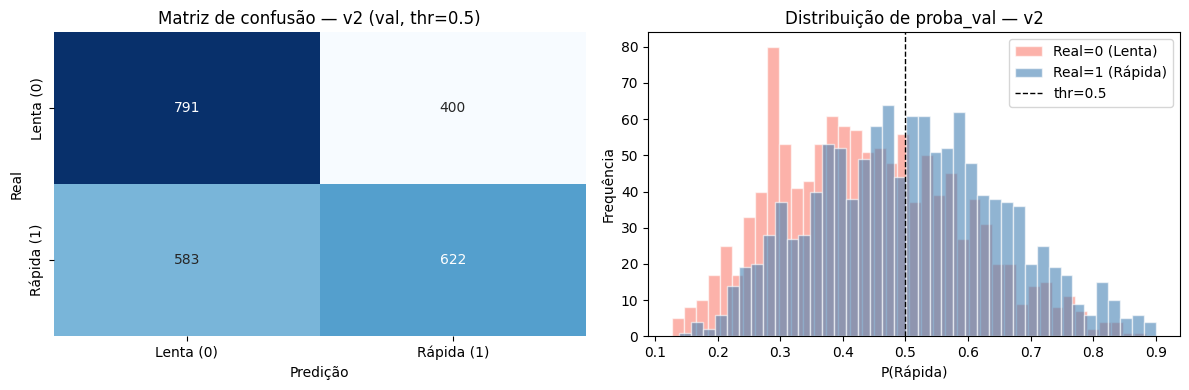

In [6]:
# ============================================================================
# Célula 7: Avaliação completa do modelo oficial (v2) no conjunto de validação
# ----------------------------------------------------------------------------
# v2 selecionado por menor gap train-val, consistente com critério do NB04.
# Aqui calculamos as 6 métricas canónicas (accuracy, precision, recall, F1,
# ROC-AUC, PR-AUC) + matriz de confusão + classification report, todas em
# threshold=0.5 (threshold definitivo só é decidido no NB06).
# ============================================================================

official_id = "v2"
official = models[official_id]

print(f"Modelo oficial : {official_id}")
print(f"Arquitetura    : hidden_layer_sizes={official.hidden_layer_sizes}, "
      f"alpha={official.alpha}")
print(f"Iterações      : {official.n_iter_}")
print()

# --- 1. Probabilidades e predições em val ---
proba_val = official.predict_proba(X_val)[:, 1]
pred_val  = (proba_val >= 0.5).astype(int)

# --- 2. Métricas globais (threshold=0.5 para as que dependem dele) ---
metrics_val = {
    "accuracy":  accuracy_score(y_val, pred_val),
    "precision": precision_score(y_val, pred_val),
    "recall":    recall_score(y_val, pred_val),
    "f1":        f1_score(y_val, pred_val),
    "roc_auc":   roc_auc_score(y_val, proba_val),      # não depende de threshold
    "pr_auc":    average_precision_score(y_val, proba_val),  # não depende de threshold
}

print("Métricas no conjunto de validação (threshold=0.5)")
print("-" * 70)
for k, v in metrics_val.items():
    print(f"  {k:10s} : {v:.4f}")
print()

# --- 3. Matriz de confusão ---
cm = confusion_matrix(y_val, pred_val)
tn, fp, fn, tp = cm.ravel()

print("Matriz de confusão (val, threshold=0.5)")
print("-" * 70)
print(f"                Pred=0 (Lenta)  Pred=1 (Rápida)")
print(f"Real=0 (Lenta)   TN = {tn:4d}        FP = {fp:4d}")
print(f"Real=1 (Rápida)  FN = {fn:4d}        TP = {tp:4d}")
print()

# --- 4. Classification report ---
print("Classification report (val)")
print("-" * 70)
print(classification_report(
    y_val, pred_val, target_names=["Lenta (0)", "Rápida (1)"], digits=4
))

# --- 5. Visualização: matriz de confusão + distribuição de probabilidades ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Heatmap da matriz de confusão
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Lenta (0)", "Rápida (1)"],
    yticklabels=["Lenta (0)", "Rápida (1)"],
    ax=axes[0], cbar=False,
)
axes[0].set_title(f"Matriz de confusão — {official_id} (val, thr=0.5)")
axes[0].set_xlabel("Predição")
axes[0].set_ylabel("Real")

# Distribuição de probabilidades por classe real
axes[1].hist(proba_val[y_val == 0], bins=40, alpha=0.6,
             label="Real=0 (Lenta)", color="salmon", edgecolor="white")
axes[1].hist(proba_val[y_val == 1], bins=40, alpha=0.6,
             label="Real=1 (Rápida)", color="steelblue", edgecolor="white")
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1, label="thr=0.5")
axes[1].set_title(f"Distribuição de proba_val — {official_id}")
axes[1].set_xlabel("P(Rápida)")
axes[1].set_ylabel("Frequência")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# ============================================================================
# Célula 8: Gerar previsões no test set com o modelo oficial (v2)
# ----------------------------------------------------------------------------
# --- 1. Probabilidades no test ---
proba_test = official.predict_proba(X_test)[:, 1]

# --- 2. Probabilidades no val (para gravação) ---
proba_val_final = official.predict_proba(X_val)[:, 1]
pred_val_final  = (proba_val_final >= 0.5).astype(int)

# --- 3. Verificação de sanidade: métricas no test (só para log, não para decisão) ---
auc_test_log = roc_auc_score(y_test, proba_test)
pr_auc_test_log = average_precision_score(y_test, proba_test)

print("Previsões geradas")
print("-" * 70)
print(f"proba_val.shape  : {proba_val_final.shape}")
print(f"proba_test.shape : {proba_test.shape}")
print()
print("Sanidade (log apenas — não usado para decisão):")
print(f"  ROC-AUC test    : {auc_test_log:.4f}   (val foi {metrics_val['roc_auc']:.4f})")
print(f"  PR-AUC  test    : {pr_auc_test_log:.4f}   (val foi {metrics_val['pr_auc']:.4f})")
print()

# --- 4. Construir DataFrames para gravação ---
val_predictions = pd.DataFrame({
    "PetID":   petids_val,
    "y_true":  y_val,
    "y_proba": proba_val_final,
    "y_pred":  pred_val_final,
})

test_predictions = pd.DataFrame({
    "PetID":   petids_test,
    "y_true":  y_test,
    "y_proba": proba_test,
    # Nota: sem y_pred, por opção metodológica (threshold só no NB06)
})

print("val_predictions")
print("-" * 70)
print(val_predictions.head())
print(f"Shape: {val_predictions.shape}")
print()
print("test_predictions")
print("-" * 70)
print(test_predictions.head())
print(f"Shape: {test_predictions.shape}")

# --- 5. Alinhamento entre val/test ROC-AUC como sanity-check de generalização ---
delta = abs(auc_test_log - metrics_val["roc_auc"])
print()
print("Diagnóstico de generalização")
print("-" * 70)
print(f"|ROC-AUC test - ROC-AUC val| = {delta:.4f}")
if delta < 0.02:
    print(">>> Excelente alinhamento val-test (diferença < 0.02).")
    print("    Sugere que val é um bom proxy para test — pipeline saudável.")
elif delta < 0.05:
    print(">>> Alinhamento aceitável val-test (diferença < 0.05).")
else:
    print(">>> ATENÇÃO: diferença val-test > 0.05. Pode indicar instabilidade.")

Previsões geradas
----------------------------------------------------------------------
proba_val.shape  : (2396,)
proba_test.shape : (2997,)

Sanidade (log apenas — não usado para decisão):
  ROC-AUC test    : 0.6407   (val foi 0.6249)
  PR-AUC  test    : 0.6231   (val foi 0.6136)

val_predictions
----------------------------------------------------------------------
       PetID  y_true   y_proba  y_pred
0  8e76c8e39       1  0.371543       0
1  c02be41e6       1  0.339788       0
2  85fc3c314       1  0.531031       1
3  eabb13cea       1  0.542729       1
4  0d25f084f       1  0.557772       1
Shape: (2396, 4)

test_predictions
----------------------------------------------------------------------
       PetID  y_true   y_proba
0  86e1089a3       1  0.633474
1  3422e4906       0  0.658860
2  7a0942d61       0  0.510904
3  b10e7605a       0  0.537969
4  6436c1a59       1  0.474575
Shape: (2997, 3)

Diagnóstico de generalização
-------------------------------------------------------

In [ ]:
# ============================================================================
# Célula 9: Gravar artefactos do NB05
# ----------------------------------------------------------------------------
# Consistente com a estrutura do NB04:
#   - 3 modelos (.joblib)
#   - val_predictions.parquet com [PetID, y_true, y_proba, y_pred]
#   - test_predictions.parquet com [PetID, y_true, y_proba]  (sem y_pred)
#   - model_comparison.csv
#   - metrics.json com métricas + findings + notas para o NB06
# ============================================================================

# --- 1. Modelos (os 3, não só o oficial) ---
for label, model in models.items():
    out_path = RESULTS_DIR / f"mlp_{label}.joblib"
    joblib.dump(model, out_path)
    print(f"Modelo {label} guardado em : {out_path}")
print()

# --- 2. Previsões val e test ---
val_path = RESULTS_DIR / "val_predictions.parquet"
test_path = RESULTS_DIR / "test_predictions.parquet"

val_predictions.to_parquet(val_path, index=False)
test_predictions.to_parquet(test_path, index=False)

print(f"val_predictions  guardado em : {val_path}  (shape {val_predictions.shape})")
print(f"test_predictions guardado em : {test_path}  (shape {test_predictions.shape})")
print()

# --- 3. Tabela comparativa dos 3 modelos ---
comparison_path = RESULTS_DIR / "model_comparison.csv"
comparison.to_csv(comparison_path, index=False)
print(f"model_comparison guardado em : {comparison_path}")
print()

# --- 4. metrics.json ---
metrics_json = {
    "notebook": "05_baseline_imagem",
    "target": "AdoptionFast (binário)",
    "input_embedding": {
        "source": "MobileNetV2 (pré-calculado no NB02)",
        "dim": 1280,
        "cache_file": "data/cache/image_embeddings_mobilenetv2.npy",
    },
    "framework": "sklearn.neural_network.MLPClassifier",
    "framework_choice_rationale": (
        "Consistência com NB04 (mesma framework) e conflito de dependências "
        "TF 2.16 vs pandas 3.x não resolvido. Fine-tuning em Keras fica para "
        "uma eventual v2 do ramo imagem."
    ),
    "models_compared": [
        {"id": r["model_id"], "hidden_layers": r["hidden_layers"],
         "alpha": r["alpha"], "n_iter": int(r["n_iter"]),
         "roc_auc_train": r["roc_auc_train"], "roc_auc_val": r["roc_auc_val"],
         "gap_train_val": r["gap_train_val"], "train_time_sec": r["train_time_sec"]}
        for r in results
    ],
    "official_model": {
        "id": official_id,
        "reason": (
            "Menor gap train-val (+0.0906) entre os modelos com ROC-AUC val "
            "próximo do topo. Critério consistente com o NB04."
        ),
        "val_metrics_threshold_0p5": {k: round(float(v), 4) for k, v in metrics_val.items()},
        "confusion_matrix_val": {
            "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
        },
        "test_metrics_log_only": {
            "roc_auc": round(float(auc_test_log), 4),
            "pr_auc":  round(float(pr_auc_test_log), 4),
        },
        "val_test_generalization_gap": round(float(abs(auc_test_log - metrics_val["roc_auc"])), 4),
    },
    "zero_embedding_group": {
        "expected": "placeholder de zeros (341 animais, 2.27%)",
        "actual_in_cache": (
            "placeholder constante de norma L2 = 24.6350 (imagem em branco "
            "processada por MobileNetV2). Todos os 341 embeddings são idênticos "
            "entre si (std por dimensão = 0). Efeito estrutural equivalente ao "
            "vetor-zero: grupo degenerado memorizável."
        ),
        "distribution_across_splits": {
            "train": 221, "val": 56, "test": 64,
        },
        "target_by_group": {
            "y_mean_with_photo_train": 0.5078,
            "y_mean_without_photo_train": 0.2851,
            "delta_pp": -22.3,
        },
        "trivial_roc_auc_has_photo_only": 0.5118,
    },
    "findings": [
        "Ramo imagem supera ramo texto em todas as 6 métricas (ROC-AUC +0.078).",
        "Ramo imagem aproxima-se do tabular (0.62 val vs 0.68 do NB03).",
        "Teto de sinal identificado em ~0.62-0.63 ROC-AUC val: os 3 modelos convergem ao mesmo ponto com early stopping paciente (30 iter no_change) e agressivo (10). Aumentar paciência não desbloqueou performance — confirma teto real, não artefacto de convergência.",
        "Modelo ligeiramente conservador em threshold=0.5: FN=583, FP=400 (razão 1.46, menos desequilibrado que NB04 v3 com razão 1.70). Threshold a otimizar no NB06.",
        "Grupo degenerado dos 341 sem foto: y_mean=0.28 vs 0.51 global (diferença -22.3 pp), consistente com sinal has_photo identificado na EDA. Pico visível em proba_val ≈ 0.29 nos histogramas.",
        "Alinhamento val-test excelente: |Δ ROC-AUC| = 0.0159. Confirma pipeline saudável.",
    ],
    "notes_for_nb06": [
        "Usar test_predictions.parquet[y_proba] como feature do ramo imagem.",
        "Não usar y_pred do val_predictions: threshold só se decide após fusão.",
        "Modelo recarregável com joblib.load(RESULTS_DIR / 'mlp_v2.joblib').",
        "Considerar criar features explícitas 'is_no_photo' e 'is_no_text' no input do modelo multimodal, para o modelo não ter de re-descobrir o sinal dos grupos degenerados.",
        "O gap de +0.09 no v2 é pequeno mas não nulo — vale monitorizar se o modelo multimodal sofre overfit similar na camada de fusão.",
    ],
}

metrics_path = RESULTS_DIR / "metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_json, f, indent=2, ensure_ascii=False)

print(f"metrics.json guardado em : {metrics_path}")
print()

# --- 5. Sumário final dos ficheiros no diretório ---
print("=" * 70)
print("Ficheiros gravados em RESULTS_DIR")
print("=" * 70)
for f in sorted(RESULTS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s}  {size_kb:8.1f} KB")

Modelo v1 guardado em : /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/results/nb05_baseline_imagem/mlp_v1.joblib
Modelo v2 guardado em : /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/results/nb05_baseline_imagem/mlp_v2.joblib
Modelo v3 guardado em : /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/results/nb05_baseline_imagem/mlp_v3.joblib

val_predictions  guardado em : /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/results/nb05_baseline_imagem/val_predictions.parquet  (shape (2396, 4))
test_predictions guardado em : /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/results/nb05_baseline_imagem/test_predictions.parquet  (shape (2997, 3))

model_comparison guardado em : /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/results/nb05_baseline_imagem/model_comparison.csv

metrics.json guardado em : /Users/rennandamiani/Documents/ISAG/ProjetoFinal_PetFinder/results/nb05_baseline_imagem/metrics.json

Ficheiros gravados em RES

## Sumário do NB05

**Modelo oficial:** MLP v2 (arquitetura média, regularização equilibrada)

**Métricas:**
- ROC-AUC val: 0.6249
- ROC-AUC test (log only, não usado para decisão): 0.6407
- Gap train-val: +0.0906

**Diagnóstico do grupo "sem foto" (341 animais):**
- Embedding placeholder constante de norma 24.6 (atribuído pelo NB02)
- Concentrados em adoção lenta (taxa de adoção rápida 22.7pp abaixo da média)
- A presença/ausência de foto torna-se uma feature implícita do modelo

**Para o NB06:**
- Usar `val_predictions.parquet[y_proba]` como feature `proba_img` do modelo de fusão
- O ranking dos baselines fica: Tabular (0.676) > Imagem (0.625) > Texto (0.547)
- A imagem traz informação real, complementar à tabular